<a href="https://colab.research.google.com/github/vanamnagasaiVarshini/thiranex_Projects/blob/main/Phishing_Email_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Phishing Email Detection Model ---
Generating synthetic dataset (200 records)...
Dataset Shape: (200, 2)
Extracting features using TF-IDF Vectorizer...
Training the classification model (Multinomial Naive Bayes)...

[Model Evaluating]
-> Training Accuracy: 100.00%
-> Testing Accuracy:  100.00%

Classification Report (Test Data):
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00        22
    Phishing       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
[[22  0]
 [ 0 18]]

=> Visual confusion matrix saved to 'confusion_matrix.png' in the current directory.

--- Try the Model interactively! ---
Type any text to simulate an email body to see how the model classifies it.
Type 'q' to quit.

Enter email text: hiiiiieeeeee
Prediction: [Phishing] => Probability of Phishing: 

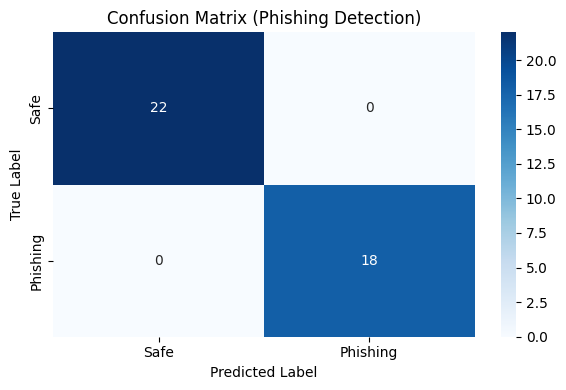

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

def generate_dataset():
    """
    Generates a small synthetic dataset of 200 emails for demo purposes.
    Label 0 = Safe, Label 1 = Phishing
    """
    safe_emails = [
        "Hey! Are we still meeting for lunch at 1pm?",
        "Don't forget the project deadline is tomorrow.",
        "Attached is the report you requested from last week.",
        "Happy birthday! Hope you have a great day.",
        "Let's review the code changes together over Zoom.",
        "The server migration was completed successfully.",
        "Can you send me the latest family photos from the trip?",
        "Your Amazon order has been shipped and is on its way.",
        "Please find the meeting minutes from yesterday's call attached.",
        "I will be on annual leave starting next Monday."
    ] * 10

    phishing_emails = [
        "URGENT: Your account has been suspended! Click here to verify your details.",
        "Verify your password immediately or you will lose access.",
        "Congratulations! You have won a $1000 gift card! Claim it now.",
        "Important Security Alert! Reset your password via this secure link.",
        "We detected suspicious activity on your account. Login to secure it.",
        "Your invoice is overdue. Please pay immediately using the attached document.",
        "Exclusive offer just for you! Click the link and claim your prize.",
        "Your email storage is full. Upgrade now to avoid profile deletion.",
        "Action Required: Complete your profile verification to unlock funds.",
        "Click this mysterious link to see a funny video of you!"
    ] * 10

    data = []
    # Append safe emails
    for text in safe_emails:
        data.append({"email_text": text, "label": 0})
    # Append phishing emails
    for text in phishing_emails:
        data.append({"email_text": text, "label": 1})

    df = pd.DataFrame(data)
    # Shuffle the dataset
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

def main():
    print("--- Phishing Email Detection Model ---")

    # 1. Provide dataset
    print("Generating synthetic dataset (200 records)...")
    df = generate_dataset()
    print(f"Dataset Shape: {df.shape}")

    # 2. Extract and analyze email features
    print("Extracting features using TF-IDF Vectorizer...")
    # TF-IDF considers term frequency while discounting very common words
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    X = vectorizer.fit_transform(df['email_text'])
    y = df['label']

    # 3. Train-test split (80% train / 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Train the Machine Learning model (MultinomialNB)
    print("Training the classification model (Multinomial Naive Bayes)...")
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # 5. Display accuracy and confusion matrix
    print("\n[Model Evaluating]")
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"-> Training Accuracy: {train_acc * 100:.2f}%")
    print(f"-> Testing Accuracy:  {test_acc * 100:.2f}%\n")

    print("Classification Report (Test Data):")
    print(classification_report(y_test, y_pred_test, target_names=["Safe", "Phishing"]))

    cm = confusion_matrix(y_test, y_pred_test)
    print("Confusion Matrix:")
    print(cm)

    # Generate Heatmap of Confusion Matrix
    try:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Safe", "Phishing"], yticklabels=["Safe", "Phishing"])
        plt.title('Confusion Matrix (Phishing Detection)')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.savefig("confusion_matrix.png")
        print("\n=> Visual confusion matrix saved to 'confusion_matrix.png' in the current directory.")
    except Exception as e:
        print(f"Could not render plot: {e}")

    print("\n" + "="*40)
    print("--- Try the Model interactively! ---")
    print("Type any text to simulate an email body to see how the model classifies it.")
    print("Type 'q' to quit.")

    while True:
        try:
            user_input = input("\nEnter email text: ")
            if user_input.lower() == 'q':
                break
            if not user_input.strip():
                continue

            # Predict the new text
            input_vector = vectorizer.transform([user_input])
            prediction = model.predict(input_vector)[0]
            probabilities = model.predict_proba(input_vector)[0]
            prob_phishing = probabilities[1]

            label = "Phishing" if prediction == 1 else "Safe"
            print(f"Prediction: [{label}] => Probability of Phishing: {prob_phishing:.2%}")

        except EOFError:
            break
        except KeyboardInterrupt:
            break

if __name__ == "__main__":
    main()